## **Support Vector Machine (Linear)**

### **Topic Roadmap**

**1. Environment Setup and Data Generation**

**2. Data Splitting**

**3. Linear SVM Implementation**

**4. Model Evaluation**

**5. Visualizing Decision Boundaries and Margins**

### **Environment Setup and Data Generation**

Import standard libraries and generate a synthetic 2D dataset. The dataset is linearly separable to demonstrate how a linear Support Vector Machine establishes a decision boundary.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.5)

### **Data Splitting**

Divide the dataset into training and testing subsets.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Linear SVM Implementation**

Train a Support Vector Classifier (SVC). Set the kernel parameter to `linear` to fit a straight hyperplane between the two classes.

In [8]:
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### **Model Evaluation**

Generate predictions on the test set and calculate the accuracy score.

In [9]:
y_pred = svm_model.predict(X_test)
print(f"Linear SVM Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Linear SVM Accuracy: 1.0000


### **Visualizing Decision Boundaries and Margins**

Extract the model's separating hyperplane and the parallel margins. Highlight the support vectors, which are the specific data points that define the margin placement.

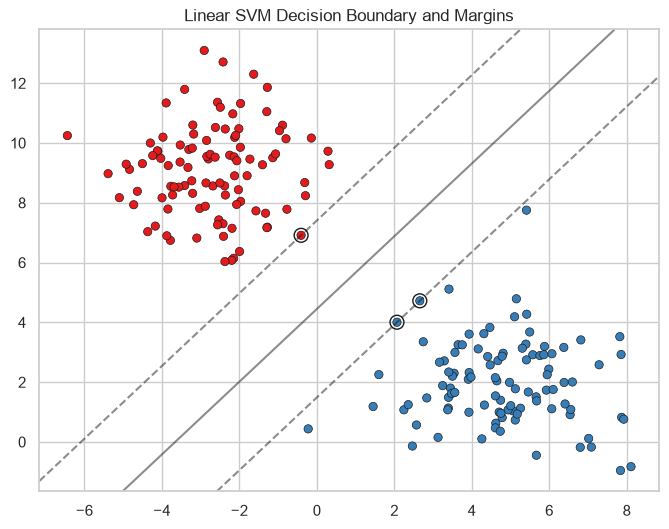

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k", legend=False)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)

# Corrected feature shape: (900, 2)
xy = np.c_[XX.ravel(), YY.ravel()]

Z = svm_model.decision_function(xy).reshape(XX.shape)

ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
ax.scatter(svm_model.support_vectors_[:, 0], svm_model.support_vectors_[:, 1], s=100, linewidth=1, facecolors='none', edgecolors='k')

plt.title('Linear SVM Decision Boundary and Margins')
plt.show()

### **Key Revision Notes**

*   **Hyperplane:** The linear decision boundary separating the classes. In 2D, it is a line.
*   **Support Vectors:** The data points closest to the hyperplane. They are the only points that influence the position and orientation of the margin.
*   **Margin:** The distance between the hyperplane and the closest support vectors from each class. SVM maximizes this margin.
*   **C Parameter (Regularization):** Controls the trade-off between achieving a wide margin and correctly classifying training points. A low `C` creates a wider margin but allows more misclassifications (soft margin). A high `C` strictly enforces correct classification, leading to a narrower margin (hard margin).